# Example: Estimating Single Index Models from Historical Data
The lecture described how the single index model (SIM) explains a firm's growth rate with one market factor. How do we estimate the model's intercept and beta for a particular firm, and how precise are those estimates?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Set up and solve the SIM regression:__ Build the design matrix and response vector from the growth rates of a firm and the market. Compute the least-squares intercept and beta three ways and check that they agree.
> * __Evaluate the fit and its uncertainty:__ Compute the residual variance, the standard errors and confidence intervals, and the coefficient of determination. Compare what these measures say about a single stock and an index fund.
> * __Estimate a whole universe of SIMs:__ Fit every security against the market and inspect the betas and the residual correlations. Save the parameter archive that the L6b portfolio examples load.

In this example, we fit the model to daily growth rates from 2014 to 2024, using the SPDR S&P 500 ETF (SPY) as the market.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
The dataset contains daily open-high-low-close (OHLC) records for firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 3, 2014 through December 31, 2024, along with records for several exchange-traded funds and volatility products. We use each day's volume-weighted average price (VWAP), stored in the `volume_weighted_average_price` column, as the share price.

Let's load the training data using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). We keep the tickers with as many records as `AAPL`, which has a full history, and store the price tables in `dataset::Dict{String,DataFrame}` and the sorted tickers in `list_of_tickers::Array{String,1}`:

In [2]:
dataset, list_of_tickers = let # variables created inside a let block stay local to it

    # Load the training prices, 2014 to 2024 -
    # |> pipes the loaded Dict into x -> x["dataset"], which returns the ticker-keyed price tables.
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has a full history
    dataset = Dict{String, DataFrame}(); # empty dictionary, filled below with complete histories

    # Keep only the tickers with as many price rows as AAPL -
    # Task 1 checks that every ticker also shares SPY's trading dates.
    for (ticker, data) ∈ original_dataset # each entry unpacks into (key, value), in no fixed order
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end

    # Sort the tickers alphabetically, which sets the column order of the growth-rate matrix -
    # The tuple unpacks into the two names on the first line.
    (dataset, keys(dataset) |> collect |> sort);
end;
println("$(length(list_of_tickers)) securities (S&P 500 firms plus a few ETFs such as SPY, QQQ,",
    " and GLD) with the full $(nrow(dataset["AAPL"])) trading days") # println joins its arguments

424 securities (S&P 500 firms plus a few ETFs such as SPY, QQQ, and GLD) with the full 2767 trading days

### Constants
Finally, we set the daily time step, the market proxy, and the tickers we study. The comments below give their meaning and units.

In [3]:
# Set the time unit, the market proxy, and the tickers we study -
Δt = (1.0/252.0); # time step (1 trading day, in years)
market_ticker = "SPY"; # the SPDR S&P 500 ETF is our proxy for the market index M
my_test_ticker = "AMD"; # the firm we fit step by step in Tasks 1 and 2 (try another ticker)
contrast_ticker = "QQQ"; # an index fund that tracks the Nasdaq-100, for contrast

# The thirteen firms of the L6a examples, shown in the Task 3 table and heatmap -
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C",
    "F", "GM", "JNJ"];

___

## Task 1: Fit the SIM for One Firm, Three Ways
In this task, we estimate the intercept and beta of one firm by least squares and check that three solution methods agree. The lecture writes the single index model for firm $i$ on trading day $t$ as:

$$
g_{i,t} = \alpha_{i} + \beta_{i}\,g_{M,t} + \varepsilon_{i,t}
$$

where $g_{M,t}$ is the market (SPY) growth rate and $\varepsilon_{i,t}$ is the residual.

### Build the growth-rate matrix
First, we build the growth-rate matrix $\mathbf{G}$, with one row per trading day and one column per ticker, [using the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix), as in L6a. The function pairs prices by row position, so we first check that every ticker shares SPY's trading dates and has positive prices. We store the matrix, in inverse years, in `G::Array{Float64,2}`:

In [4]:
G = let

    # Check the inputs that log_growth_matrix does not check -
    # It pairs prices by row position, so every ticker must share SPY's trading dates.
    for ticker ∈ list_of_tickers
        prices = dataset[ticker].volume_weighted_average_price; # daily VWAP (USD/share)
        @assert dataset[ticker].timestamp == dataset[market_ticker].timestamp # same dates
        @assert all(isfinite, prices) && all(>(0), prices) # >(0) means x -> x > 0
    end

    # Build G (N days × one column per ticker), growth rates in 1/yr -
    # Δt = Δt passes our Δt as a keyword argument. The risk-free rate keeps its default of zero.
    log_growth_matrix(dataset, list_of_tickers, Δt = Δt); # the let block returns this matrix
end;
N, number_of_securities = size(G); # size returns (rows, columns)
println("N = $(N) daily growth-rate observations for $(number_of_securities) securities")

N = 2766 daily growth-rate observations for 424 securities


### Set up the regression
Next, we pull out the market growth rates into `g_market::Array{Float64,1}` and the test firm's growth rates into the response vector $\mathbf{y}$, stored in `y::Array{Float64,1}`. As in the lecture, the design matrix $\hat{\mathbf{X}}$ has a column of ones for the intercept and a column of market growth rates, so $\mathbf{y}=\hat{\mathbf{X}}\boldsymbol{\theta}+\boldsymbol{\varepsilon}$ with $\boldsymbol{\theta}=(\alpha_{i},\beta_{i})^{\top}$. We store it in `X̂::Array{Float64,2}`:

In [5]:
# Pull out the market and test-firm columns of G -
# findfirst(==(t), list) returns the position of ticker t, where ==(t) means x -> x == t.
g_market = G[:, findfirst(==(market_ticker), list_of_tickers)]; # market growth rates g_M,t (1/yr)
y = G[:, findfirst(==(my_test_ticker), list_of_tickers)]; # test-firm growth rates g_i,t (1/yr)

# Build the design matrix X̂ = [1 g_M], an N × 2 array -
X̂ = [ones(N) g_market]; # a space between the two vectors places them side by side as columns
size(X̂) # (N, 2)

(2766, 2)

### Solve three ways
The least-squares estimate minimizes $\lVert\mathbf{y}-\hat{\mathbf{X}}\boldsymbol{\theta}\rVert_{2}^{2}$. We compute it three ways:

* __Normal equations:__ Solve the $2\times2$ system $(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})\,\hat{\boldsymbol{\theta}}=\hat{\mathbf{X}}^{\top}\mathbf{y}$ from the lecture.
* __Backslash:__ [The `\` operator](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/) computes `X̂ \ y` from a QR factorization of $\hat{\mathbf{X}}$, without forming $\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}$.
* __Singular value decomposition:__ [The `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) factors $\hat{\mathbf{X}}=\mathbf{U}\mathbf{\Sigma}\mathbf{V}^{\top}$, so $\hat{\boldsymbol{\theta}}=\mathbf{V}\mathbf{\Sigma}^{-1}\mathbf{U}^{\top}\mathbf{y}$. The ratio of the largest to the smallest singular value is the condition number.

The three agree when $\hat{\mathbf{X}}$ has full column rank, which we check [using the `rank(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank). We store the backslash solution in `θ̂::Array{Float64,1}`:

In [6]:
θ̂ = let

    # Check that the least-squares solution is unique -
    @assert rank(X̂) == 2 # full column rank: both singular values are well above zero

    # Solve three ways -
    θ_normal = (transpose(X̂)*X̂) \ (transpose(X̂)*y); # normal equations, a 2×2 linear system
    θ_qr = X̂ \ y; # for a tall matrix, \ returns the least-squares solution (QR factorization)
    F = svd(X̂); # X̂ = U Σ Vᵀ: F.U is N × 2, F.S holds the singular values (largest first)
    θ_svd = F.V*(Diagonal(1 ./ F.S)*(transpose(F.U)*y)); # V Σ⁻¹ Uᵀ y, 1 ./ F.S inverts each entry

    # Check that the three solutions agree, then report the condition number -
    @assert isapprox(θ_normal, θ_qr, rtol = 1e-10) && isapprox(θ_svd, θ_qr, rtol = 1e-10)
    println("Condition number of X̂ (ratio of singular values): $(round(F.S[1]/F.S[2], digits=3))")
    θ_qr; # return the backslash solution
end;
println("$(my_test_ticker): α̂ = $(round(θ̂[1], digits=4)) 1/yr, β̂ = $(round(θ̂[2], digits=4))")

Condition number of X̂ (ratio of singular values): 2.151


AMD: α̂ = 0.1275 1/yr, β̂ = 1.7392


All three methods give the same estimate, and the condition number is small. The methods differ on badly conditioned problems, such as regressions on several correlated factors, where the normal equations usually lose accuracy first.

Let's plot the firm's growth rate against the market's, with the fitted line, [using the `scatter(...)` function](https://docs.juliaplots.org/stable/api/#Plots.scatter-Tuple):

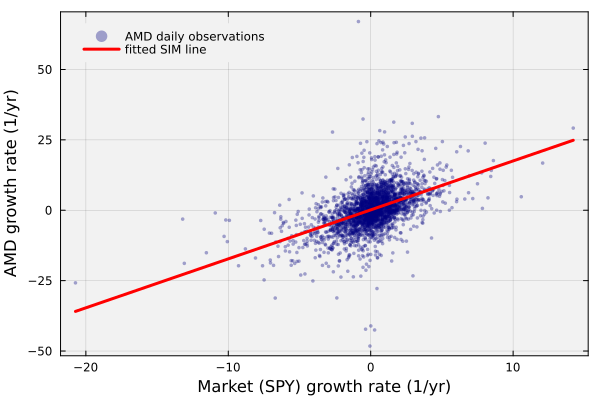

In [7]:
let
    # Plot each trading day as one point: (market growth rate, firm growth rate) -
    # ms is the marker size, msw the marker outline width, and alpha the transparency.
    scatter(g_market, y, ms = 2, msw = 0, alpha = 0.35, c = :navy,
        label = "$(my_test_ticker) daily observations")

    # Overlay the fitted line α̂ + β̂ g_M across the observed market range -
    # plot! (with the !) adds to the current figure instead of starting a new one.
    xs = range(minimum(g_market), maximum(g_market), length = 50);
    plot!(xs, θ̂[1] .+ θ̂[2] .* xs, c = :red, lw = 3, label = "fitted SIM line")

    # Label the axes and style the canvas -
    plot!(xlabel = "Market ($(market_ticker)) growth rate (1/yr)",
        ylabel = "$(my_test_ticker) growth rate (1/yr)",
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :topleft)
end

__What do we see?__ Each point is one trading day. The point's height above or below the line is that day's residual. In Task 2, we measure how much of the firm's variation the line explains.
___

## Task 2: Evaluate the Fit and Its Uncertainty
In this task, we measure how much of the test firm's growth rate the market explains and how precisely we have estimated alpha and beta.

### Residual variance and goodness of fit
As in the lecture, the residuals $\mathbf{r}=\mathbf{y}-\hat{\mathbf{X}}\hat{\boldsymbol{\theta}}$ give the residual variance and the coefficient of determination:

$$
s^{2}_{g,\varepsilon} = \frac{\lVert\mathbf{r}\rVert_{2}^{2}}{N-2},
\qquad
R^{2} = 1-\frac{\lVert\mathbf{r}\rVert_{2}^{2}}{\sum_{t=1}^{N}\left(g_{i,t}-g^{\prime}_{i}\right)^{2}}
$$

where $g^{\prime}_{i}$ is the sample mean of the firm's growth rates. With an intercept in the model, $R^{2}$ equals the squared correlation between the firm and the market, which we check [using the `cor(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cor). We store the results in `s²_gε::Float64` and `R²::Float64`:

In [8]:
s²_gε, R² = let

    # Residuals and residual variance -
    r = y .- X̂*θ̂; # residual growth rates (1/yr)
    s² = dot(r, r)/(N - 2); # residual growth-rate variance with the N - 2 divisor (1/yr²)
    @assert isapprox(s², var(r)*(N - 1)/(N - 2), rtol = 1e-10) # var divides by N - 1 instead

    # Coefficient of determination -
    R² = 1 - dot(r, r)/sum(abs2, y .- mean(y)); # abs2 squares each entry
    # With an intercept, R² equals the squared correlation between y and g_market.
    @assert isapprox(R², cor(y, g_market)^2, rtol = 1e-10)
    (s², R²); # return
end;
println("$(my_test_ticker): residual growth-rate std s_gε = $(round(sqrt(s²_gε), digits=3)) 1/yr,",
    " R² = $(round(R², digits=3))")

AMD: residual growth-rate std s_gε = 6.541 1/yr, R² = 0.245


### Standard errors and confidence intervals
As in the lecture, the standard errors are the square roots of the diagonal entries of $s^{2}_{g,\varepsilon}(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}$. A 95% confidence interval is the estimate plus or minus $t_{0.975,N-2}\approx1.96$ standard errors, where the critical value comes from [the `TDist` distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.TDist).

These intervals assume errors that are uncorrelated across days with constant variance. The optional [residual diagnostics notebook](advanced/diagnostics/CHEME-5660-L6b-Advanced-SIM-Diagnostics-Fall-2026.ipynb) checks for dependence across days.

We store the standard errors in `SE::Array{Float64,1}` and tabulate the intervals [using the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table):

In [9]:
# Classical standard errors, the square roots of the diagonal of s² (X̂ᵀX̂)⁻¹ -
# (X̂ᵀX̂) \ I solves against the 2 × 2 identity matrix, which returns the inverse.
SE = sqrt.(s²_gε .* diag((transpose(X̂)*X̂) \ I)); # SE(α̂) in 1/yr, SE(β̂) dimensionless
let
    # Two-sided 95% critical value, Student t with N - 2 degrees of freedom -
    t = quantile(TDist(N - 2), 0.975);

    # Build and display the interval table -
    # cond ? a : b returns a when cond is true and b otherwise.
    df = DataFrame(parameter = ["α (1/yr)", "β"], estimate = round.(θ̂, digits=4),
        SE = round.(SE, digits=4),
        CI_low = round.(θ̂ .- t*SE, digits=4), CI_high = round.(θ̂ .+ t*SE, digits=4),
        covers_zero = [(θ̂[j] - t*SE[j] ≤ 0 ≤ θ̂[j] + t*SE[j]) ? "yes" : "no" for j ∈ 1:2]);
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------- ---------- --------- --------- --------- -------------
  parameter   estimate        SE    CI_low   CI_high   covers_zero 
     String    Float64   Float64   Float64   Float64        String 
 ----------- ---------- --------- --------- --------- -------------
   α (1/yr)     0.1275    0.1245   -0.1167    0.3716           yes
          β     1.7392     0.058    1.6254    1.8529            no
 ----------- ---------- --------- --------- --------- -------------


__How do we read the table?__

* __Beta:__ A narrow interval means the data pin down the firm's market exposure. Check whether it lies above one, below one, or covers one.
* __Alpha:__ Alpha intervals are usually wide relative to the estimate. If the interval covers zero, the data cannot separate the firm's average growth rate from what its market exposure alone delivers.
* __Goodness of fit:__ The printed $R^{2}$ is the fraction of the firm's daily variation that the market explains.

If you change `my_test_ticker`, your values will differ.
___

## Task 3: Fit the SIM for Every Security
In this task, we fit the SIM for every security, check whether their residuals are correlated, and save the parameters for the L6b portfolio examples.

### Fit every security
We repeat the Task 1 and Task 2 calculations for every column of $\mathbf{G}$. Each ticker's estimates, standard errors, intervals, residual variance, and $R^{2}$ go into a [NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple), collected in `sim_parameters::Dict{String,NamedTuple}`. We also keep the residuals, one column per ticker, in `E::Array{Float64,2}`.

As a check, SPY regressed on itself gives $\alpha=0$, $\beta=1$, and $R^{2}=1$. We leave SPY out of the summaries that follow:

In [10]:
sim_parameters, E = let

    # Quantities shared by every regression (same design matrix X̂) -
    XtX_inv = (transpose(X̂)*X̂) \ I; # (X̂ᵀX̂)⁻¹, the 2 × 2 inverse, computed by a solve
    t = quantile(TDist(N - 2), 0.975); # two-sided 95% critical value
    parameters = Dict{String, NamedTuple}(); # ticker => estimates
    E = Array{Float64,2}(undef, N, number_of_securities); # residuals, one column per ticker

    # Fit each security against the market -
    for (i, ticker) ∈ enumerate(list_of_tickers) # column i of G belongs to list_of_tickers[i]
        yᵢ = G[:, i]; # growth rates of security i (1/yr)
        θᵢ = X̂ \ yᵢ; # least-squares [α̂, β̂]
        rᵢ = yᵢ .- X̂*θᵢ; # residuals (1/yr)
        E[:, i] = rᵢ; # keep them for the residual check
        s²ᵢ = dot(rᵢ, rᵢ)/(N - 2); # residual growth-rate variance (1/yr²)
        SEᵢ = sqrt.(s²ᵢ .* diag(XtX_inv)); # classical standard errors
        R²ᵢ = 1 - dot(rᵢ, rᵢ)/sum(abs2, yᵢ .- mean(yᵢ)); # coefficient of determination

        # Store the results as a NamedTuple, where training_variance is s²_gε (1/yr²) -
        parameters[ticker] = (ticker = ticker, n_observations = N, n_parameters = 2,
            critical_value_95 = t, alpha = θᵢ[1], beta = θᵢ[2], alpha_SE = SEᵢ[1], beta_SE = SEᵢ[2],
            alpha_95_CI_lower = θᵢ[1] - t*SEᵢ[1], alpha_95_CI_upper = θᵢ[1] + t*SEᵢ[1],
            beta_95_CI_lower = θᵢ[2] - t*SEᵢ[2], beta_95_CI_upper = θᵢ[2] + t*SEᵢ[2],
            training_variance = s²ᵢ, r_squared = R²ᵢ);
    end

    # Check: the market regressed on itself gives α = 0, β = 1, and R² = 1 -
    spy = parameters[market_ticker];
    @assert isapprox(spy.alpha, 0.0, atol = 1e-10) && isapprox(spy.beta, 1.0, atol = 1e-10)
    @assert isapprox(spy.r_squared, 1.0, atol = 1e-10)
    (parameters, E); # return
end;
println("Estimated $(length(sim_parameters)) single index models")

Estimated 424 single index models


### Compare a stock with an index fund
Every fit is now stored in `sim_parameters`. Let's compare the test firm with `contrast_ticker`, an index fund that tracks the Nasdaq-100:

In [11]:
let
    # Collect the two fits from sim_parameters, one table row per ticker -
    df = DataFrame(ticker = String[], α = Float64[], β = Float64[], SE_β = Float64[],
        s_gε = Float64[], R² = Float64[]);
    for ticker ∈ [my_test_ticker, contrast_ticker]
        d = sim_parameters[ticker]; # NamedTuple of estimates, fields read with a dot
        push!(df, (ticker = ticker, α = round(d.alpha, digits=4), β = round(d.beta, digits=4),
            SE_β = round(d.beta_SE, digits=4), s_gε = round(sqrt(d.training_variance), digits=3),
            R² = round(d.r_squared, digits=3)));
    end

    # Display the table -
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- --------- ---------
  ticker         α         β      SE_β      s_gε        R² 
  String   Float64   Float64   Float64   Float64   Float64 
 -------- --------- --------- --------- --------- ---------
     AMD    0.1275    1.7392     0.058     6.541     0.245
     QQQ    0.0413    1.1348    0.0094     1.057     0.841
 -------- --------- --------- --------- --------- ---------


__What do we see?__ An index fund holds many stocks, so much of their residual risk diversifies away and its $R^{2}$ is high. A single stock keeps its own residual, so its $R^{2}$ is lower, whatever its beta.

### Betas and fit across the dataset
Let's look at the thirteen L6a firms in `my_list_of_tickers`. The column `s_gε` is the residual growth-rate standard deviation (1/yr):

In [12]:
let
    # Collect one row per L6a firm from sim_parameters -
    df = DataFrame(ticker = String[], α = Float64[], β = Float64[], SE_β = Float64[],
        s_gε = Float64[], R² = Float64[]);
    for ticker ∈ my_list_of_tickers
        d = sim_parameters[ticker];
        push!(df, (ticker = ticker, α = round(d.alpha, digits=3), β = round(d.beta, digits=3),
            SE_β = round(d.beta_SE, digits=3), s_gε = round(sqrt(d.training_variance), digits=3),
            R² = round(d.r_squared, digits=3)));
    end

    # Display the table -
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- --------- ---------
  ticker         α         β      SE_β      s_gε        R² 
  String   Float64   Float64   Float64   Float64   Float64 
 -------- --------- --------- --------- --------- ---------
    AAPL     0.106     1.195     0.024     2.701     0.474
    MSFT       0.1     1.152     0.021     2.366     0.522
    INTC    -0.148     1.184     0.035     3.921     0.296
      MU    -0.053     1.695     0.047     5.333     0.317
     AMD     0.127     1.739     0.058     6.541     0.245
    NVDA     0.347     1.749     0.043     4.898      0.37
      GS    -0.033      1.31     0.024     2.703      0.52
     BAC    -0.055     1.359     0.028     3.114     0.467
     WFC    -0.091     1.238     0.029     3.269     0.398
       C    -0.133     1.501     0.028     3.171     0.508
       F    -0.193     1.434     0.036     4.071     0.363
      GM    -0.129      1.47     0.036     4.012     0.382
     JNJ    -0.016      0.54     0.019     2.149    

__What do we see?__ The health-care firm has the lowest beta, near 0.5. Three of the four semiconductor firms have the highest, near 1.7, and the largest residual standard deviations.

How are the betas and $R^{2}$ values distributed across the whole dataset? Let's plot both [using the `histogram(...)` function](https://docs.juliaplots.org/stable/api/#Plots.histogram-Tuple):

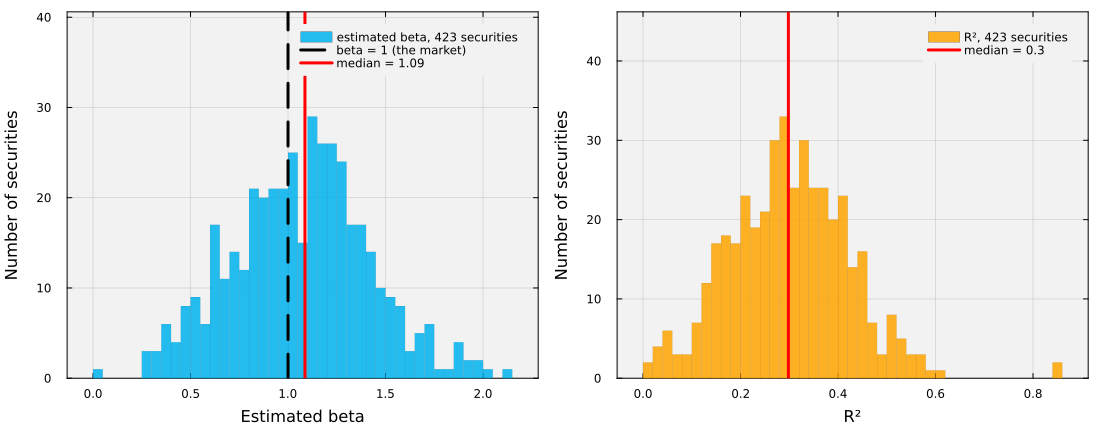

In [13]:
let
    # Collect beta and R² for every security except the market itself -
    others = filter(!=(market_ticker), list_of_tickers); # !=(x) means y -> y != x
    βs = [sim_parameters[t].beta for t ∈ others];
    R²s = [sim_parameters[t].r_squared for t ∈ others];

    # Left panel: the distribution of estimated betas -
    p1 = histogram(βs, bins = 40, c = :deepskyblue2, lw = 0, alpha = 0.85,
        label = "estimated beta, $(length(βs)) securities",
        xlabel = "Estimated beta", ylabel = "Number of securities")
    vline!(p1, [1.0], c = :black, lw = 3, ls = :dash, label = "beta = 1 (the market)")
    vline!(p1, [median(βs)], c = :red, lw = 3, label = "median = $(round(median(βs), digits=2))")
    ylims!(p1, (0, 1.4*Plots.ylims(p1)[2])) # headroom above the tallest bar for the legend

    # Right panel: the distribution of R² -
    p2 = histogram(R²s, bins = 40, c = :orange, lw = 0, alpha = 0.85,
        label = "R², $(length(R²s)) securities",
        xlabel = "R²", ylabel = "Number of securities")
    vline!(p2, [median(R²s)], c = :red, lw = 3, label = "median = $(round(median(R²s), digits=2))")
    ylims!(p2, (0, 1.4*Plots.ylims(p2)[2]))

    # Combine the two panels side by side -
    plot(p1, p2, layout = (1, 2), size = (1100, 430), legend = :topright,
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
end

### Check the residual correlations
The lecture's SIM covariance, $\mathbf{\Sigma}_{g}=\sigma^{2}_{g,M}\boldsymbol{\beta}\boldsymbol{\beta}^{\top}+\mathbf{D}_{g}$, assumes that the residuals of different securities are __uncorrelated__. Least squares makes each residual vector orthogonal to the market column, but not to the other residuals.

Let's summarize the correlations among all residuals (SPY excluded) and show those of the L6a firms [using the `heatmap(...)` function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple):

Off-diagonal residual correlations across 423 securities:


  median |ρ| = 0.073
  95th percentile of |ρ| = 0.273
  largest |ρ| = 0.981, for FOXA and FOX


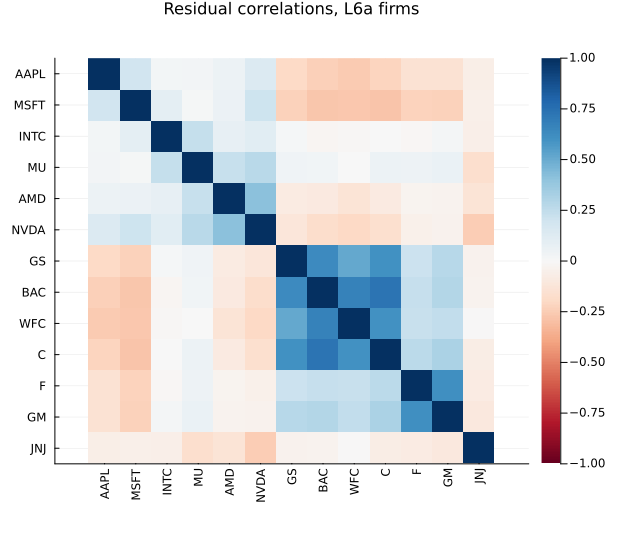

In [14]:
let
    # Correlation matrix of the residuals, SPY excluded (its residuals are zero up to roundoff) -
    others = findall(!=(market_ticker), list_of_tickers); # column positions of every other security
    ρ_E = cor(E[:, others]); # cor correlates the columns of a matrix

    # Summarize the off-diagonal entries, taking each pair once from the lower triangle -
    pairs = [(i, j) for i ∈ 1:length(others) for j ∈ 1:(i-1)];
    offdiag = [ρ_E[i, j] for (i, j) ∈ pairs];
    k = argmax(abs.(offdiag)); # position of the most correlated pair
    (i_max, j_max) = pairs[k];
    println("Off-diagonal residual correlations across $(length(others)) securities:")
    println("  median |ρ| = $(round(median(abs.(offdiag)), digits=3))")
    println("  95th percentile of |ρ| = $(round(quantile(abs.(offdiag), 0.95), digits=3))")
    pair = "$(list_of_tickers[others[i_max]]) and $(list_of_tickers[others[j_max]])";
    println("  largest |ρ| = $(round(abs(offdiag[k]), digits=3)), for $(pair)")

    # Heatmap of the residual correlations among the L6a firms -
    M = length(my_list_of_tickers);
    idx = [findfirst(==(t), list_of_tickers) for t ∈ my_list_of_tickers];
    # right_margin leaves room for the colorbar labels.
    heatmap(cor(E[:, idx]), xticks = (1:M, my_list_of_tickers), yticks = (1:M, my_list_of_tickers),
        xrotation = 90, color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1),
        aspect_ratio = :equal, yflip = true, title = "Residual correlations, L6a firms",
        titlefontsize = 11, right_margin = 10Plots.mm, size = (640, 540))
end

__What do we see?__

* __Most pairs:__ The median $|\rho|$ is small, so a zero residual correlation is a good approximation for most pairs.
* __Related firms:__ Bank residuals correlate at about 0.5 to 0.7, and the two automakers at about 0.6. The AAPL and MSFT residuals are negatively correlated with the bank residuals.
* __Near-duplicates:__ The most correlated pair, two share classes of one firm, is almost perfectly correlated.

The SIM covariance sets all of these correlations to zero. The [SIM portfolio example](CHEME-5660-L6b-Example-SIM-MinVar-RA-Fall-2026.ipynb) measures how much that changes the chosen portfolios.

### Save the parameter archive
Finally, we save the parameters and their metadata to [data/SIMs-SP500-01-03-14-to-12-31-24.jld2](data/SIMs-SP500-01-03-14-to-12-31-24.jld2) [using the `save(...)` function](https://juliaio.github.io/JLD2.jl/stable/#save-and-load) from JLD2:

In [15]:
let
    # Write the parameters and their metadata to one JLD2 file -
    path_to_save_file = joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2");
    save(path_to_save_file, Dict(
        "data" => sim_parameters,
        "market_ticker" => market_ticker,
        "market_mean" => mean(g_market), # training-period mean market growth rate (1/yr)
        "market_variance" => var(g_market), # training-period market growth-rate variance (1/yr²)
        "delta_t" => Δt,
        "growth_definition" => "g_t = log(S_t/S_{t-1})/Δt with S the volume-weighted " *
            "average price; units 1/years; no risk-free rate subtracted", # * joins the two strings
        "date_range" => (string(dataset[market_ticker].timestamp[1]),
            string(dataset[market_ticker].timestamp[end])),
        "list_of_tickers" => list_of_tickers,
        "variance_convention" => "growth_rate", # training_variance is s²_gε in 1/yr²
        "schema_version" => 2 # the portfolio examples check this version number
    ));
    println("Saved $(length(sim_parameters)) SIM parameter sets to ",
        relpath(path_to_save_file, _ROOT))
end

Saved 424 SIM parameter sets to data/SIMs-SP500-01-03-14-to-12-31-24.jld2

___

## Summary
In this example, we fit the single index model to one firm and then to every security in the dataset, and saved the parameters for the L6b portfolio examples.

> __Key Takeaways:__
>
> * **Three methods, one estimate:** We solved the least-squares problem with the normal equations, a QR-based solve, and the singular value decomposition and got the same intercept and beta. The methods differ in numerical accuracy, which matters for badly conditioned problems.
> * **Exposure and fit are different measures:** We computed standard errors, confidence intervals, and the coefficient of determination, and found beta estimated far more precisely than alpha. The index fund had a much higher coefficient of determination than the single stock, because much of its residual risk diversifies away.
> * **Related firms keep correlated residuals:** We fit every security against the market, found betas from near zero to above two, and saved the parameters. Most residual correlations were near zero, but related firms such as banks stayed correlated, and the SIM covariance sets these correlations to zero.

Next, [the uncertainty example](CHEME-5660-L6b-Example-SIM-Parameter-Uncertainty-Fall-2026.ipynb) asks how much alpha and beta could change with another dataset. [The SIM portfolio example](CHEME-5660-L6b-Example-SIM-MinVar-RA-Fall-2026.ipynb) builds the SIM covariance matrix from this archive.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___